# Accuracies from any results CSV

Point `RESULTS` at a results CSV and run all cells. Produces two frames to plot from:

| | what it is |
|---|---|
| `agg` | exactly what `calculate_accuracies.accuracies()` returns — `skip_config`, `accuracy_mean`, `accuracy_std`, `order` |
| `tidy` | the same means/stds, but with the config split into real columns (`translator_method`, `translator_rank`, `fit_dataset`, `params_saved_pct`, …) so you can group and plot without parsing strings |

`agg` is the canonical output and is written to disk. `tidy` is a convenience view built from
the same per-seed rows — it never recomputes the accuracy, only re-attaches the columns that
`skip_config` flattens into one string.

In [9]:
from pathlib import Path
import sys

import pandas as pd

# Repo root, whether the notebook is opened from analysis/ or from the root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "skipping_heads"))

from calculate_accuracies import accuracies  # the project's own aggregation

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

# ---- set this -------------------------------------------------------------------------
RESULTS = ROOT / "results" / "results_lowrank.csv"
# Where to write the aggregated CSV. None -> alongside the input as accuracies_<name>.
OUTPUT = None
# ---------------------------------------------------------------------------------------

OUTPUT = Path(OUTPUT) if OUTPUT else RESULTS.with_name(f"accuracies_{RESULTS.name}")
print(f"in  : {RESULTS}\nout : {OUTPUT}")
print(f"exists: {RESULTS.exists()}")

if not RESULTS.exists():
    print("\navailable results CSVs:")
    for p in sorted((ROOT / "results").glob("*.csv")):
        print(f"  {p.name}")

in  : /Users/mabelwylie/Documents/toast-extensions/results/results_lowrank.csv
out : /Users/mabelwylie/Documents/toast-extensions/results/accuracies_results_lowrank.csv
exists: True


## 1. Aggregate

Calls the project's `accuracies()` unchanged, so the output matches what the SLURM scripts write.

In [10]:
raw = pd.read_csv(RESULTS)
agg = accuracies(RESULTS, OUTPUT)

print(f"{len(raw)} per-seed rows -> {len(agg)} unique configs")
print(f"seeds present: {sorted(raw['seed'].unique())}")
agg.head()

183 per-seed rows -> 61 unique configs
seeds present: [np.int64(1), np.int64(2), np.int64(3)]


,skip_config,accuracy_mean,accuracy_std,order
60,"Encoder: facebook/dinov2-base, Dataset: imagenet-1k, Blo...",0.742767,0.004649,0
40,"Encoder: facebook/dinov2-base, Dataset: imagenet-1k, Blo...",0.293200,0.000400,3
41,"Encoder: facebook/dinov2-base, Dataset: imagenet-1k, Blo...",0.733167,0.003988,6
53,"Encoder: facebook/dinov2-base, Dataset: imagenet-1k, Blo...",0.026667,0.001607,9
49,"Encoder: facebook/dinov2-base, Dataset: imagenet-1k, Blo...",0.046833,0.001762,12


## 2. Sanity checks

Run these before plotting. Each corresponds to a way results have silently gone wrong before:
a collapsed probe reads as a real number, a missing baseline reads as "no accuracy lost", and
an interrupted sweep leaves configs with fewer seeds than the rest.

In [11]:
def sanity(df):
    # 1. Collapsed probes: a probe scoring the majority-class rate has learned nothing.
    if "majority_class_rate" in df and df["majority_class_rate"].notna().any():
        d = df.dropna(subset=["majority_class_rate"])
        bad = d[d["accuracy"] <= d["majority_class_rate"] + 1e-6]
        print(f"[collapse] {len(bad)}/{len(d)} rows at or below the majority-class rate")
        if len(bad):
            print(bad.groupby("dataset")
                    .agg(rows=("accuracy", "size"),
                         majority=("majority_class_rate", "first"),
                         mean_acc=("accuracy", "mean")).round(4))
            print("           ^ these configs are null results, not findings")
    else:
        print("[collapse] no majority_class_rate column (results predate it) -- cannot check")

    # 2. Missing baselines. NaN delta_acc means no baseline row was found; 0.0 in an older
    #    file is ambiguous, since that used to mean the same thing.
    if "delta_acc" in df:
        n_nan = df["delta_acc"].isna().sum()
        print(f"[baseline] {n_nan}/{len(df)} rows with NaN delta_acc (no baseline row found)")
        if n_nan:
            miss = df[df["delta_acc"].isna()][["dataset", "model"]].drop_duplicates()
            print(miss.to_string(index=False))

    # 3. Uneven seed counts -- an interrupted sweep, so some means average fewer runs.
    key = [c for c in ("dataset", "model", "approx_layer", "mlp_linearize",
                       "attn_linearize", "translator", "fit_dataset") if c in df]
    counts = df.groupby(key, dropna=False).size()
    print(f"[seeds] configs have {sorted(counts.unique())} seeds each")
    if counts.nunique() > 1:
        print(f"        {(counts < counts.max()).sum()} config(s) below the max -- "
              f"their means average fewer seeds")

sanity(raw)

[collapse] 0/183 rows at or below the majority-class rate
[baseline] 0/183 rows with NaN delta_acc (no baseline row found)
[seeds] configs have [np.int64(3)] seeds each


## 3. Tidy frame

Same means and stds, with the config as columns instead of one flattened string. Groups on
whichever config columns the file actually has, so it works on old and new results alike.

In [12]:
def tidy_frame(df):
    """Per-config mean/std, keeping the config fields as separate columns.

    Grouped on the same fields calculate_accuracies uses, plus fit_dataset -- a transfer row
    is identical to its same-dataset control in every other column, so omitting it would
    average the two together.
    """
    group = [c for c in ("dataset", "fit_dataset", "model", "approx_layer", "translator",
                         "translator_method", "translator_rank", "mlp_linearize", "mlp_mode",
                         "attn_linearize", "attn_mode", "head_dict") if c in df]

    carry = {c: (c, "first") for c in
             ("params_saved", "params_saved_pct", "num_layers", "majority_class_rate")
             if c in df}

    out = (df.groupby(group, dropna=False)
             .agg(accuracy_mean=("accuracy", "mean"),
                  accuracy_std=("accuracy", "std"),
                  n_seeds=("accuracy", "size"),
                  **carry)
             .reset_index())

    # Accuracy relative to this dataset+model's own unedited baseline, recomputed from the
    # means rather than read from delta_acc (which is per-seed and NaN when the baseline row
    # is absent).
    is_base = (out["approx_layer"] == "[]")
    if "mlp_linearize" in out:
        is_base &= (out["mlp_linearize"] == "[]")
    if "attn_linearize" in out:
        is_base &= (out["attn_linearize"] == "[]")

    base = (out[is_base].groupby(["dataset", "model"])["accuracy_mean"]
                        .mean().rename("baseline_mean"))
    out = out.merge(base, on=["dataset", "model"], how="left")
    out["drop_from_baseline"] = out["baseline_mean"] - out["accuracy_mean"]
    out["is_baseline"] = is_base.values

    return out.sort_values(["dataset", "model", "approx_layer"]).reset_index(drop=True)

tidy = tidy_frame(raw)
print(f"{len(tidy)} configs | columns: {list(tidy.columns)}")
tidy.head(20)

61 configs | columns: ['dataset', 'fit_dataset', 'model', 'approx_layer', 'translator', 'translator_method', 'translator_rank', 'mlp_linearize', 'mlp_mode', 'attn_linearize', 'attn_mode', 'head_dict', 'accuracy_mean', 'accuracy_std', 'n_seeds', 'params_saved', 'params_saved_pct', 'num_layers', 'majority_class_rate', 'baseline_mean', 'drop_from_baseline', 'is_baseline']


,dataset,fit_dataset,model,approx_layer,translator,translator_method,translator_rank,mlp_linearize,mlp_mode,attn_linearize,...,accuracy_mean,accuracy_std,n_seeds,params_saved,params_saved_pct,num_layers,majority_class_rate,baseline_mean,drop_from_baseline,is_baseline
0,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",identity,NaN,NaN,[],identity,[],...,0.654133,0.003530,3,7089408,8.333333,1,0.0019,0.742767,0.088633,False
1,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",linear,NaN,NaN,[],identity,[],...,0.739867,0.003612,3,6498816,7.639115,1,0.0019,0.742767,0.002900,False
2,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lora_128,lora,128.0,[],identity,[],...,0.242300,0.002835,3,6892800,8.102228,1,0.0019,0.742767,0.500467,False
3,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lora_16,lora,16.0,[],identity,[],...,0.006767,0.001002,3,7064832,8.304445,1,0.0019,0.742767,0.736000,False
4,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lora_256,lora,256.0,[],identity,[],...,0.684333,0.002248,3,6696192,7.871123,1,0.0019,0.742767,0.058433,False
5,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lora_32,lora,32.0,[],identity,[],...,0.013833,0.002150,3,7040256,8.275557,1,0.0019,0.742767,0.728933,False
6,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lora_64,lora,64.0,[],identity,[],...,0.029333,0.003459,3,6991104,8.217781,1,0.0019,0.742767,0.713433,False
7,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lora_8,lora,8.0,[],identity,[],...,0.005233,0.000681,3,7077120,8.318889,1,0.0019,0.742767,0.737533,False
8,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lowrank_128,lowrank,128.0,[],identity,[],...,0.018767,0.000808,3,6892800,8.102228,1,0.0019,0.742767,0.724000,False
9,imagenet-1k,imagenet-1k,facebook/dinov2-base,"[(0, 1)]",lowrank_16,lowrank,16.0,[],identity,[],...,0.009100,0.000346,3,7064832,8.304445,1,0.0019,0.742767,0.733667,False


## 4. Experiment-specific views

Each cell no-ops if the file isn't from that experiment, so it's safe to run all of them.

In [13]:
# --- rank sweep: accuracy vs rank, one column per method -------------------------------
if "translator_rank" in tidy and tidy["translator_rank"].notna().any():
    rank = tidy[tidy["translator_rank"].notna()]
    rank_pivot = rank.pivot_table(index=["approx_layer", "translator_rank"],
                                  columns="translator_method",
                                  values="accuracy_mean")

    # Reference lines: identity floor and full-rank linear, per span.
    ref = (tidy[tidy["translator"].isin(["identity", "linear"]) & ~tidy["is_baseline"]]
           .pivot_table(index="approx_layer", columns="translator", values="accuracy_mean"))

    print("accuracy vs rank:")
    display(rank_pivot.round(4))
    print("\nreference (no rank):")
    display(ref.round(4))
    print(f"\nbaseline (no skip): {tidy.loc[tidy['is_baseline'], 'accuracy_mean'].mean():.4f}")
else:
    rank_pivot = ref = None
    print("no translator_rank column -- not a rank sweep")

accuracy vs rank:


translator_method               lora  lowrank     rrr
approx_layer translator_rank                         
[(0, 1)]     8.0              0.0052   0.0066  0.0155
             16.0             0.0068   0.0091  0.0299
             32.0             0.0138   0.0119  0.0717
             64.0             0.0293   0.0110  0.3164
             128.0            0.2423   0.0188  0.6180
             256.0            0.6843   0.0524  0.7239
[(2, 4)]     8.0              0.0089   0.0197  0.0326
             16.0             0.0247   0.0284  0.0866
             32.0             0.0665   0.0389  0.1669
             64.0             0.2215   0.0476  0.4035
             128.0            0.5073   0.0596  0.6018
             256.0            0.6448   0.3721  0.6732
[(5, 6)]     8.0              0.0136   0.0267  0.0499
             16.0             0.0313   0.0468  0.1048
             32.0             0.0673   0.0766  0.2559
             64.0             0.3141   0.0967  0.5183
             128.0            0.6473   0.1740  0.6817
             256.0            0.7184   0.6066  0.7184


reference (no rank):


translator,identity,linear
approx_layer,,
"[(0, 1)]",0.6541,0.7399
"[(2, 4)]",0.0943,0.6869
"[(5, 6)]",0.2932,0.7332



baseline (no skip): 0.7428


In [14]:
# --- transfer: accuracy by where the translator was fitted -----------------------------
if "fit_dataset" in tidy and tidy["fit_dataset"].notna().any():
    tr = tidy[tidy["fit_dataset"].notna() & ~tidy["is_baseline"]].copy()
    tr["transfer"] = tr["fit_dataset"] != tr["dataset"]
    if tr["transfer"].any():
        transfer = tr.pivot_table(index=["dataset", "approx_layer"],
                                  columns="fit_dataset", values="accuracy_mean")
        print("accuracy by fitting dataset (columns) vs evaluation dataset (rows):")
        display(transfer.round(4))
        print("\nThe control is the cell where fit_dataset == dataset. If it does not match")
        print("the same config run without a fit_dataset, the reload is not working and no")
        print("other cell in this table means anything.")
    else:
        transfer = None
        print("fit_dataset present but never differs from dataset -- no transfer rows")
else:
    transfer = None
    print("no fit_dataset column -- not a transfer sweep")

fit_dataset present but never differs from dataset -- no transfer rows


In [15]:
# --- table 3: whole-block vs MLP-only vs attention-only, at matched savings -------------
def arm(row):
    if row.get("is_baseline"):
        return "baseline"
    if row["approx_layer"] != "[]":
        return f"block ({row['translator']})"
    if row.get("mlp_linearize", "[]") != "[]":
        return f"mlp ({row['mlp_mode']})"
    if row.get("attn_linearize", "[]") != "[]":
        return f"attn ({row['attn_mode']})"
    return "other"

t3 = tidy.copy()
t3["arm"] = t3.apply(arm, axis=1)
if t3["arm"].nunique() > 2:
    # Blocks removed is the common axis across the three arms.
    t3["blocks"] = t3.apply(
        lambda r: r["mlp_linearize"] if r["approx_layer"] == "[]" and r.get("mlp_linearize", "[]") != "[]"
        else (r["attn_linearize"] if r["approx_layer"] == "[]" and r.get("attn_linearize", "[]") != "[]"
              else r["approx_layer"]), axis=1)
    table3 = t3[~t3["is_baseline"]].pivot_table(
        index=["dataset", "model", "blocks"], columns="arm", values="accuracy_mean")
    print("accuracy by removal strategy:")
    display(table3.round(4))
else:
    table3 = None
    print("only one removal strategy present -- not a table-3 style sweep")

accuracy by removal strategy:


arm                                        block (identity)  block (linear)  block (lora_128)  block (lora_16)  block (lora_256)  block (lora_32)  block (lora_64)  block (lora_8)  \
dataset     model                blocks                                                                                                                                              
imagenet-1k facebook/dinov2-base [(0, 1)]            0.6541          0.7399            0.2423           0.0068            0.6843           0.0138           0.0293          0.0052   
                                 [(2, 4)]            0.0943          0.6869            0.5073           0.0247            0.6448           0.0665           0.2215          0.0089   
                                 [(5, 6)]            0.2932          0.7332            0.6473           0.0313            0.7184           0.0673           0.3141          0.0136   

arm                                        block (lowrank_128)  block (lowrank_16)  block (lowrank_256)  block (lowrank_32)  block (lowrank_64)  block (lowrank_8)  block (rrr_128)  block (rrr_16)  \
dataset     model                blocks                                                                                                                                                               
imagenet-1k facebook/dinov2-base [(0, 1)]               0.0188              0.0091               0.0524              0.0119              0.0110             0.0066           0.6180          0.0299   
                                 [(2, 4)]               0.0596              0.0284               0.3721              0.0389              0.0476             0.0197           0.6018          0.0866   
                                 [(5, 6)]               0.1740              0.0468               0.6066              0.0766              0.0967             0.0267           0.6817          0.1048   

arm                                        block (rrr_256)  block (rrr_32)  block (rrr_64)  block (rrr_8)  
dataset     model                blocks                                                                    
imagenet-1k facebook/dinov2-base [(0, 1)]           0.7239          0.0717          0.3164         0.0155  
                                 [(2, 4)]           0.6732          0.1669          0.4035         0.0326  
                                 [(5, 6)]           0.7184          0.2559          0.5183         0.0499

## 5. Plot from here

Available: `agg` (project format), `tidy` (columns), and whichever of `rank_pivot`, `ref`,
`transfer`, `table3` applied.

Useful columns on `tidy`: `accuracy_mean`, `accuracy_std`, `n_seeds`, `drop_from_baseline`,
`params_saved_pct`, `translator_method`, `translator_rank`, `fit_dataset`.

Two things worth carrying onto any figure: use `accuracy_std` for error bars (and check
`n_seeds` is equal across the configs being compared), and for a rank sweep plot rank on a log
axis, since the grid is powers of two.

In [16]:
tidy.to_csv(OUTPUT.with_name(f"tidy_{RESULTS.name}"), index=False)
print(f"agg  -> {OUTPUT}")
print(f"tidy -> {OUTPUT.with_name(f'tidy_{RESULTS.name}')}")

agg  -> /Users/mabelwylie/Documents/toast-extensions/results/accuracies_results_lowrank.csv
tidy -> /Users/mabelwylie/Documents/toast-extensions/results/tidy_results_lowrank.csv


In [18]:
### just for lowrank

tidy["translator_rank"] = tidy["translator_rank"].apply(lambda x: int(x) if pd.notna(x) else 768)  # for nicer display
tidy["translator_method"] = tidy["translator_method"].fillna("identity")  # for nicer display

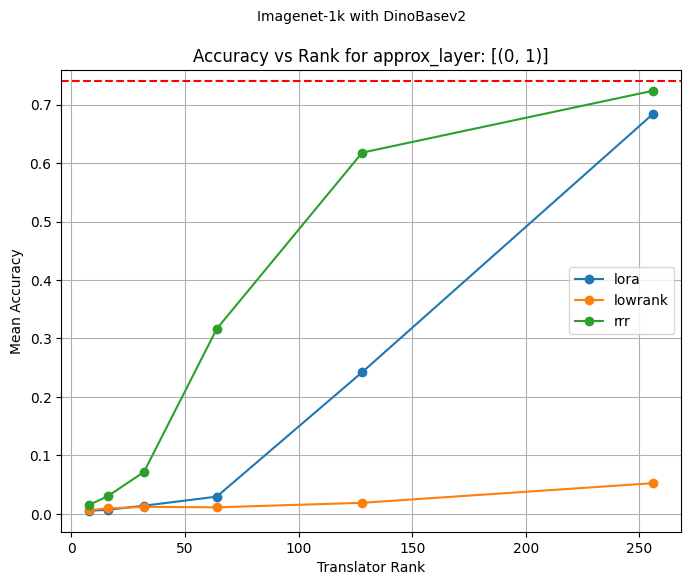

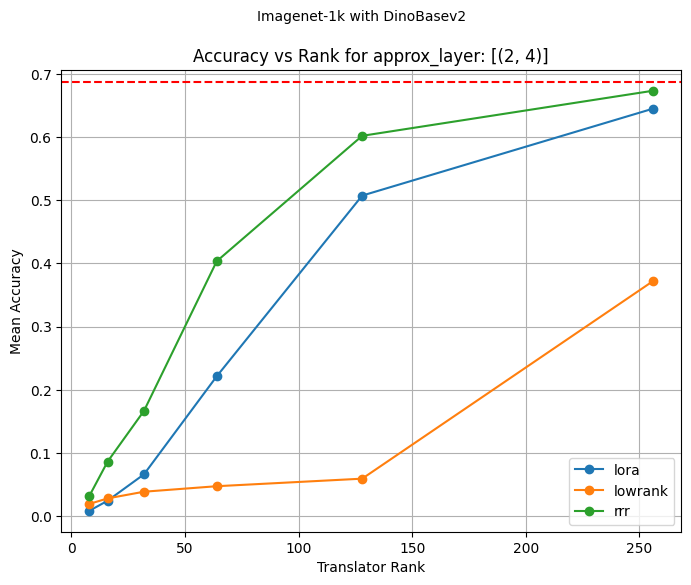

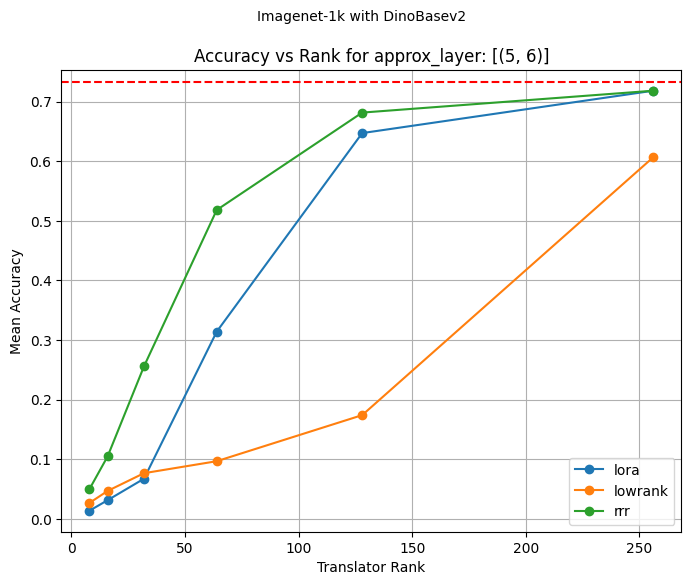

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_18925/2814052681.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


IndexError: index 1 is out of bounds for axis 0 with size 1

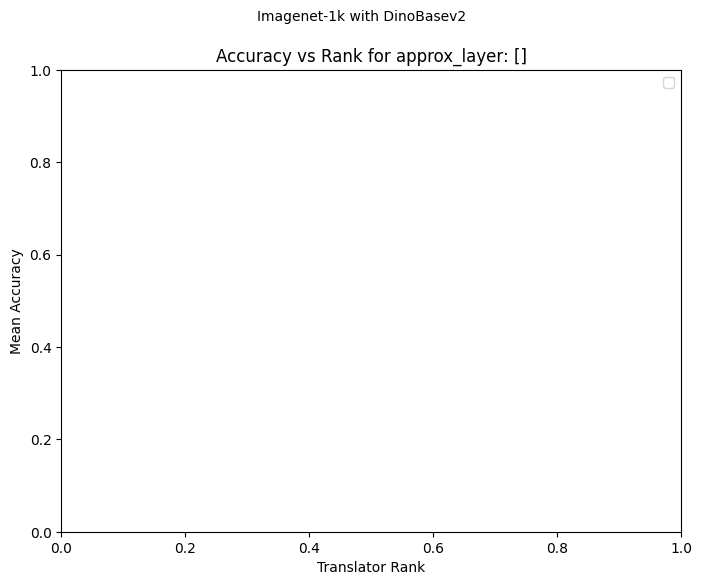

In [27]:
import matplotlib.pyplot as plt
# different plot for each approx_layer
# plot the accuracy vs rank for each approx_layer
for approx_layer in tidy["approx_layer"].unique():
    layer_df = tidy[tidy["approx_layer"] == approx_layer]
    plt.figure(figsize=(8, 6))
    for method in layer_df["translator_method"].unique():
        if method == "identity":
            continue  # skip identity method
        method_df = layer_df[layer_df["translator_method"] == method]
        method_df = method_df.sort_values("translator_rank")
        plt.plot(method_df["translator_rank"], method_df["accuracy_mean"], marker='o', label=method)
    plt.title(f'Accuracy vs Rank for approx_layer: {approx_layer}')
    plt.suptitle('Imagenet-1k with DinoBasev2', fontsize=10)
    plt.xlabel('Translator Rank')
    plt.ylabel('Mean Accuracy')
    plt.legend()
    # put a horizontal line for the identity method's accuracy
    identity_df = layer_df[layer_df["translator_method"] == "identity"]
    if not identity_df.empty:
        identity_acc = identity_df["accuracy_mean"].values[1]
        plt.axhline(y=identity_acc, color='r', linestyle='--', label='Identity Accuracy')
    plt.grid()
    plt.show()
        

